In [123]:
# Install Dependencies

!pip install tensorflow-model-optimization
!pip install ai-edge-litert
!pip install joblib

In [124]:
# Imports

import os
import glob
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_model_optimization as tfmot

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import train_test_split

from tensorflow.keras import (
    layers,
    models,
    callbacks
)

warnings.filterwarnings(
    "ignore",
    category=UserWarning
)

%matplotlib inline

In [125]:
# Mount Google Drive

%matplotlib inline

from google.colab import drive

google_drive_path = "/content/drive"

## Mount Google Drive
drive.mount(google_drive_path, force_remount=True)

## Project custom drive path
my_path = "AG/FH/study/AI_IoT/node/milestone2"

## Declare project home directory
project_path = f"{google_drive_path}/MyDrive/{my_path}"
os.makedirs(project_path, exist_ok=True)


## Dataset directory
dataset_dir = "device_native_dataset"

## Declare project dataset path
dataset_path = f"{google_drive_path}/MyDrive/{my_path}/{dataset_dir}"

## Output Device native
os.makedirs(f"{project_path}/output", exist_ok=True)
OUTPUT_DIR = f"{project_path}/output/device_native"



MODEL_DIR = f"{OUTPUT_DIR}/models"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

Mounted at /content/drive


In [126]:
# Configuration

TARGET_NAMES = [
    "STATIONARY",
    "WALKING"
]

LABEL_MAP = {
    "STATIONARY": 0,
    "WALKING": 1
}

WINDOW_SIZE = 50
WINDOW_STEP = 25

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [127]:
# Feature Extraction Function

def extract_features_window(window):

    feats = []

    # Mean + Std
    for axis in range(6):
        feats.append(np.mean(window[:, axis]))
        feats.append(np.std(window[:, axis]))

    # Min + Max
    for axis in range(6):
        feats.append(np.min(window[:, axis]))
        feats.append(np.max(window[:, axis]))

    # Mean absolute acceleration
    feats.append(
        np.sum(np.abs(window[:, :3])) / window.shape[0]
    )

    # Mean absolute gyroscope
    feats.append(
        np.sum(np.abs(window[:, 3:])) / window.shape[0]
    )

    # Acceleration magnitude
    acc_mag = np.linalg.norm(window[:, :3], axis=1)

    feats.append(np.mean(acc_mag))
    feats.append(np.std(acc_mag))

    return np.array(feats)

In [128]:
# Load Dataset Files

csv_files = glob.glob(
    os.path.join(dataset_path, "*.csv")
)

if len(csv_files) == 0:
    raise RuntimeError(
        f"No CSV files found in: {DATASET_DIR}"
    )

print("\nDetected dataset files:\n")

for f in csv_files:
    print(f)


Detected dataset files:

/content/drive/MyDrive/AG/FH/study/AI_IoT/node/milestone2/device_native_dataset/STATIONARY_20260510_194427.csv
/content/drive/MyDrive/AG/FH/study/AI_IoT/node/milestone2/device_native_dataset/WALKING_20260510_193844.csv


In [129]:
# Generate Windows + Features

all_windows = []
all_labels = []

for file_path in csv_files:

    print(f"\nProcessing: {file_path}")

    df = pd.read_csv(file_path)

    required_cols = [
        "ax", "ay", "az",
        "gx", "gy", "gz",
        "label"
    ]

    for col in required_cols:
        if col not in df.columns:
            raise RuntimeError(
                f"Missing column '{col}'"
            )

    label_name = df["label"].iloc[0]

    if label_name not in LABEL_MAP:
        print(f"Skipping unknown label: {label_name}")
        continue

    label = LABEL_MAP[label_name]

    sensor_data = df[
        [
            "ax", "ay", "az",
            "gx", "gy", "gz"
        ]
    ].values

    # Sliding windows
    for start in range(
        0,
        len(sensor_data) - WINDOW_SIZE,
        WINDOW_STEP
    ):

        end = start + WINDOW_SIZE

        window = sensor_data[start:end]

        feats = extract_features_window(window)

        all_windows.append(feats)
        all_labels.append(label)

X = np.array(all_windows)
y = np.array(all_labels)

print("\nDataset Summary")
print("--------------------")
print("X shape:", X.shape)
print("y shape:", y.shape)

unique, counts = np.unique(y, return_counts=True)

for u, c in zip(unique, counts):
    print(f"{TARGET_NAMES[u]}: {c}")


Processing: /content/drive/MyDrive/AG/FH/study/AI_IoT/node/milestone2/device_native_dataset/STATIONARY_20260510_194427.csv

Processing: /content/drive/MyDrive/AG/FH/study/AI_IoT/node/milestone2/device_native_dataset/WALKING_20260510_193844.csv

Dataset Summary
--------------------
X shape: (1198, 28)
y shape: (1198,)
STATIONARY: 599
WALKING: 599


In [130]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (958, 28)
Test : (240, 28)


In [131]:
# Feature Scaling

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

joblib.dump(
    scaler,
    f"{MODEL_DIR}/scaler.pkl"
)

print("Saved scaler.pkl")

Saved scaler.pkl


In [132]:
# Build Model

model = models.Sequential([
    layers.Input(
        shape=(X_train_sc.shape[1],)
    ),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dense(
        2,
        activation="softmax"
    )
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 994 (3.88 KB)

 Trainable params: 994 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [133]:
# Train Model

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_sc,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_sc, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9749 - loss: 0.2330 - val_accuracy: 1.0000 - val_loss: 0.0579
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 1.0000 - loss: 0.0363 - val_accuracy: 1.0000 - val_loss: 0.0198
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 1.0000 - loss: 0.0165 - val_accuracy: 1.0000 - val_loss: 0.0112
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 1.0000 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 0.0074
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.0071 - val_accuracy: 1.0000 - val_loss: 0.0053
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - v

In [134]:
# Save Keras Model

keras_model_path = (
    f"{MODEL_DIR}/device_native_model.keras"
)

model.save(keras_model_path)

print("Saved:")
print(keras_model_path)

Saved:
/content/drive/MyDrive/AG/FH/study/AI_IoT/node/milestone2/output/device_native/models/device_native_model.keras


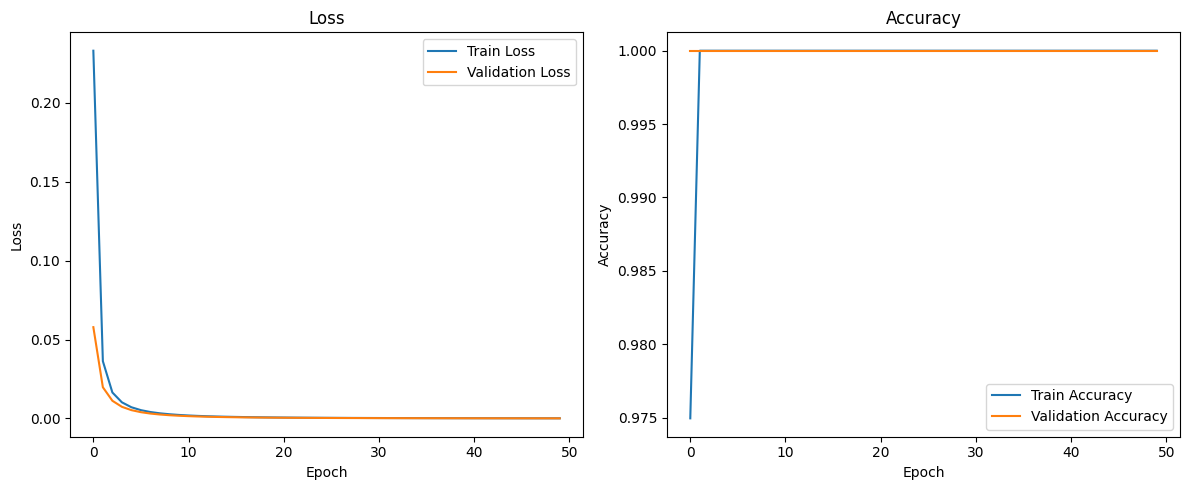

Saved training_curves.png


In [135]:
# Plot Training Curves

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/training_curves.png",
    dpi=150
)

plt.show()

print("Saved training_curves.png")

In [136]:
# Evaluation

y_pred = np.argmax(
    model.predict(X_test_sc),
    axis=1
)

print("\nUnique y_test labels:")
print(np.unique(y_test))

print("\nUnique y_pred labels:")
print(np.unique(y_pred))

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=TARGET_NAMES,
        zero_division=0
    )
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Unique y_test labels:
[0 1]

Unique y_pred labels:
[0 1]

Classification Report

              precision    recall  f1-score   support

  STATIONARY       1.00      1.00      1.00       120
     WALKING       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



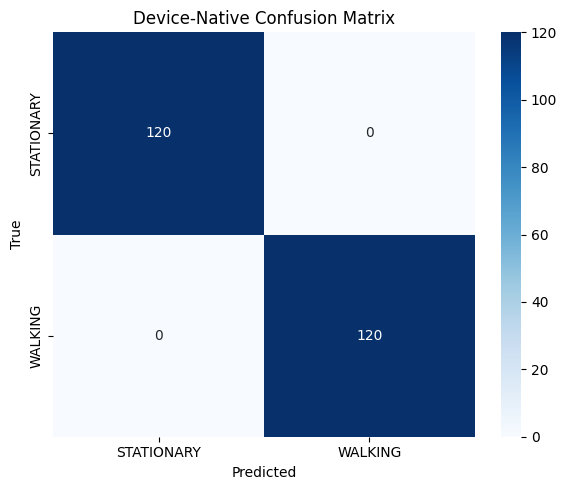

Saved confusion_matrix.png


In [137]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=TARGET_NAMES,
    yticklabels=TARGET_NAMES
)

plt.title(
    "Device-Native Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/confusion_matrix.png",
    dpi=150
)

plt.show()

print("Saved confusion_matrix.png")

In [138]:
# Export Float32 TFLite

converter = tf.lite.TFLiteConverter.from_keras_model(
    model
)

tflite_model = converter.convert()

tflite_path = (
    f"{MODEL_DIR}/device_native_model.tflite"
)

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print("Saved:")
print(tflite_path)

Saved artifact at '/tmp/tmpmehnc8ea'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28), dtype=tf.float32, name='keras_tensor_15')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  134112976125392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134112969471568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134112969462928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134112908308944: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved:
/content/drive/MyDrive/AG/FH/study/AI_IoT/node/milestone2/output/device_native/models/device_native_model.tflite


In [139]:
# INT8 Quantisation

def representative_dataset():

    for i in range(
        min(100, len(X_train_sc))
    ):

        yield [
            np.array(
                [X_train_sc[i]],
                dtype=np.float32
            )
        ]

converter_int8 = (
    tf.lite.TFLiteConverter.from_keras_model(
        model
    )
)

converter_int8.optimizations = [
    tf.lite.Optimize.DEFAULT
]

converter_int8.representative_dataset = (
    representative_dataset
)

converter_int8.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter_int8.inference_input_type = tf.int8
converter_int8.inference_output_type = tf.int8

tflite_quant_model = converter_int8.convert()

quant_path = (
    f"{MODEL_DIR}/device_native_model_int8.tflite"
)

with open(quant_path, "wb") as f:
    f.write(tflite_quant_model)

print("Saved:")
print(quant_path)

Saved artifact at '/tmp/tmpe1rkwx2i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28), dtype=tf.float32, name='keras_tensor_15')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  134112976125392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134112969471568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134112969462928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134112908308944: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved:
/content/drive/MyDrive/AG/FH/study/AI_IoT/node/milestone2/output/device_native/models/device_native_model_int8.tflite


In [140]:
# Export Scaler Parameters

scaler_params = {
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist()
}

scaler_json_path = (
    f"{MODEL_DIR}/scaler_params.json"
)

with open(scaler_json_path, "w") as f:

    json.dump(
        scaler_params,
        f,
        indent=4
    )

print("Saved:")
print(scaler_json_path)

Saved:
/content/drive/MyDrive/AG/FH/study/AI_IoT/node/milestone2/output/device_native/models/scaler_params.json


In [141]:
# Model Size Report

float_size = (
    os.path.getsize(tflite_path) / 1024
)

int8_size = (
    os.path.getsize(quant_path) / 1024
)

print("\nModel Size Report")
print("------------------------")

print(
    f"Float32 TFLite : "
    f"{float_size:.2f} KB"
)

print(
    f"INT8 TFLite    : "
    f"{int8_size:.2f} KB"
)


Model Size Report
------------------------
Float32 TFLite : 5.61 KB
INT8 TFLite    : 3.78 KB


In [142]:
# Final Completion

print("\nPipeline Complete.")

print("\nGenerated Outputs:")

print("\nModels:")
print("- device_native_model.keras")
print("- device_native_model.tflite")
print("- device_native_model_int8.tflite")

print("\nEvaluation:")
print("- training_curves.png")
print("- confusion_matrix.png")

print("\nScaler:")
print("- scaler.pkl")
print("- scaler_params.json")


Pipeline Complete.

Generated Outputs:

Models:
- device_native_model.keras
- device_native_model.tflite
- device_native_model_int8.tflite

Evaluation:
- training_curves.png
- confusion_matrix.png

Scaler:
- scaler.pkl
- scaler_params.json


In [144]:
print(df['label'].value_counts())

# Option 1 — NumPy
unique, counts = np.unique(y_test, return_counts=True)
print(dict(zip(unique, counts)))

# Option 2 — Convert to Pandas Series
print(pd.Series(y_test).value_counts())

# Predictions distribution
print(np.unique(y_pred, return_counts=True))

label
WALKING    15001
Name: count, dtype: int64
{0: 120, 1: 120}
1    120
0    120
Name: count, dtype: int64
(array([0, 1]), array([120, 120]))
